# 01 - Data Audit and Exploratory Data Analysis

This notebook is the presentation-facing EDA for the project. It answers three questions:

1. Do we have enough clean data from both Bluesky and Yahoo Finance?
2. What does social sentiment look like across tickers and time?
3. How did the EDA inform the final hybrid intraday/overnight modeling dataset?

The most useful charts are saved to `outputs/figures/` for slides and dashboard reuse.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

from src.config import CLEAN_FINANCE_START, FEATURE_DATASET_PATH, FIGURES_DIR
from src.data_loading import load_feature_data, load_merged_data, summarize_data_quality
from src.feature_engineering import build_clean_hourly_dataset
from src.plots import set_plot_style

set_plot_style()
sns.set_context("talk", font_scale=0.85)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 220

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

raw_df = load_merged_data()
feature_df = load_feature_data()

print(f"Raw merged rows: {raw_df.height:,} rows x {raw_df.width:,} columns")
print(f"Final modeling rows: {feature_df.height:,} rows x {feature_df.width:,} columns")
print(f"Clean finance start used for modeling: {CLEAN_FINANCE_START:%Y-%m-%d}")


Raw merged rows: 194,891 rows x 10 columns
Final modeling rows: 13,325 rows x 70 columns
Clean finance start used for modeling: 2024-06-01


## Data Sources and Project Unit

The raw dataset combines two public sources:

- **Bluesky posts** mentioning stock cashtags such as `$AAPL` and `$NVDA`.
- **Yahoo Finance hourly OHLCV bars** for the same tickers.

The raw file is post-level: multiple posts can exist for the same ticker-hour. For modeling, we aggregate posts into one ticker-hour signal so highly discussed hours do not get duplicated as multiple training rows.


In [2]:
quality = summarize_data_quality(raw_df)
clean_hourly_df = build_clean_hourly_dataset(raw_df)

summary_rows = [
    ("Raw merged rows", f"{raw_df.height:,}"),
    ("Raw columns", f"{raw_df.width:,}"),
    ("Unique tickers", f"{raw_df['Ticker'].n_unique():,}"),
    ("Unique raw ticker-hours", f"{quality['unique_ticker_hours']:,}"),
    ("Duplicate post keys", f"{quality['duplicate_post_keys']:,}"),
    ("Raw timestamp min", str(quality["timestamp_min"])),
    ("Raw timestamp max", str(quality["timestamp_max"])),
    ("Clean ticker-hours after finance filter", f"{clean_hourly_df.height:,}"),
    ("Final labeled modeling rows", f"{feature_df.height:,}"),
    ("Final feature columns", f"{feature_df.width:,}"),
]

summary_table = pd.DataFrame(summary_rows, columns=["Check", "Value"])
display(summary_table)

null_summary = raw_df.null_count().transpose(
    include_header=True,
    header_name="Column",
    column_names=["Null Count"],
).sort("Null Count", descending=True)
display(null_summary)


,Check,Value
0,Raw merged rows,"194,891"
1,Raw columns,10
2,Unique tickers,23
3,Unique raw ticker-hours,"55,982"
4,Duplicate post keys,"3,870"
5,Raw timestamp min,2009-01-02 03:00:00+00:00
6,Raw timestamp max,2026-04-28 23:00:00+00:00
7,Clean ticker-hours after finance filter,"54,572"
8,Final labeled modeling rows,"13,325"
9,Final feature columns,70


Column,Null Count
str,u32
"""Ticker""",0
"""Timestamp""",0
"""Text""",0
"""Sentiment""",0
"""Post_Count""",0
"""Open""",0
"""High""",0
"""Low""",0
"""Close""",0


**EDA takeaway.** The raw file is comfortably above the 50,000-row requirement and contains both social and financial variables. The modeling dataset is smaller because it uses only reliable recent hourly finance coverage, aggregates duplicate ticker-hours, and drops neutral target moves below the return threshold.


## EDA Assumptions, Biases, and Limitations

The EDA is used to decide whether the data is appropriate for short-term directional modeling, not to prove that social sentiment causes price movement. Several assumptions and bias risks are important for the rubric and for honest interpretation:

- **Source and selection bias:** Bluesky users are not representative of all investors. The sample overrepresents people who post publicly, use cashtags, and discuss high-attention stocks. This creates an attention bias toward meme stocks, large technology names, and unusually active news periods.
- **Ticker-selection bias:** The 23 tickers were chosen because they are liquid and socially discussed. Results should not be generalized to all equities, low-volume securities, or long-horizon investing without collecting a broader ticker universe.
- **API/search bias:** Bluesky search can miss deleted posts, private activity, posts without cashtags, or posts that the API ranking does not surface. We therefore interpret post volume as observed social activity, not the full market conversation.
- **Text-model bias:** FinBERT is finance-specific, which is better than generic sentiment, but social-media language includes sarcasm, memes, emojis, ticker spam, and ambiguous context. Neutral dominance in the distribution is a real finding, but also partly reflects the difficulty of classifying short social posts.
- **Market-data assumptions:** Yahoo Finance hourly data is a public, convenient source, but hourly bars are not tick-level tradable prices. Forward/backward filling financial values for off-market posts preserves the social observation while using the last/next observed market context; it should not be interpreted as a real off-hours transaction price.
- **Temporal bias and nonstationarity:** The dataset is especially active near April 2026, and market behavior changes over time. This is why the modeling notebook uses chronological splits and why we avoid claiming that one static relationship will hold in future regimes.
- **Target-definition tradeoff:** Dropping returns inside +/-0.1% removes noisy tiny moves and improves label clarity, but it also removes many ordinary market hours. The final model answers a narrower question: can sentiment help classify clearer up/down moves?

These limitations directly inform the roadmap: aggregate to ticker-hour observations, include ticker and activity features, use time-aware validation, compare multiple metrics, and present the final result as limited directional signal rather than a trading rule.

## Visual 1 - Data Coverage by Ticker

This chart checks whether the social data is concentrated in only one or two tickers. Uneven attention is expected in financial social media, but the model should know which tickers dominate the training signal.


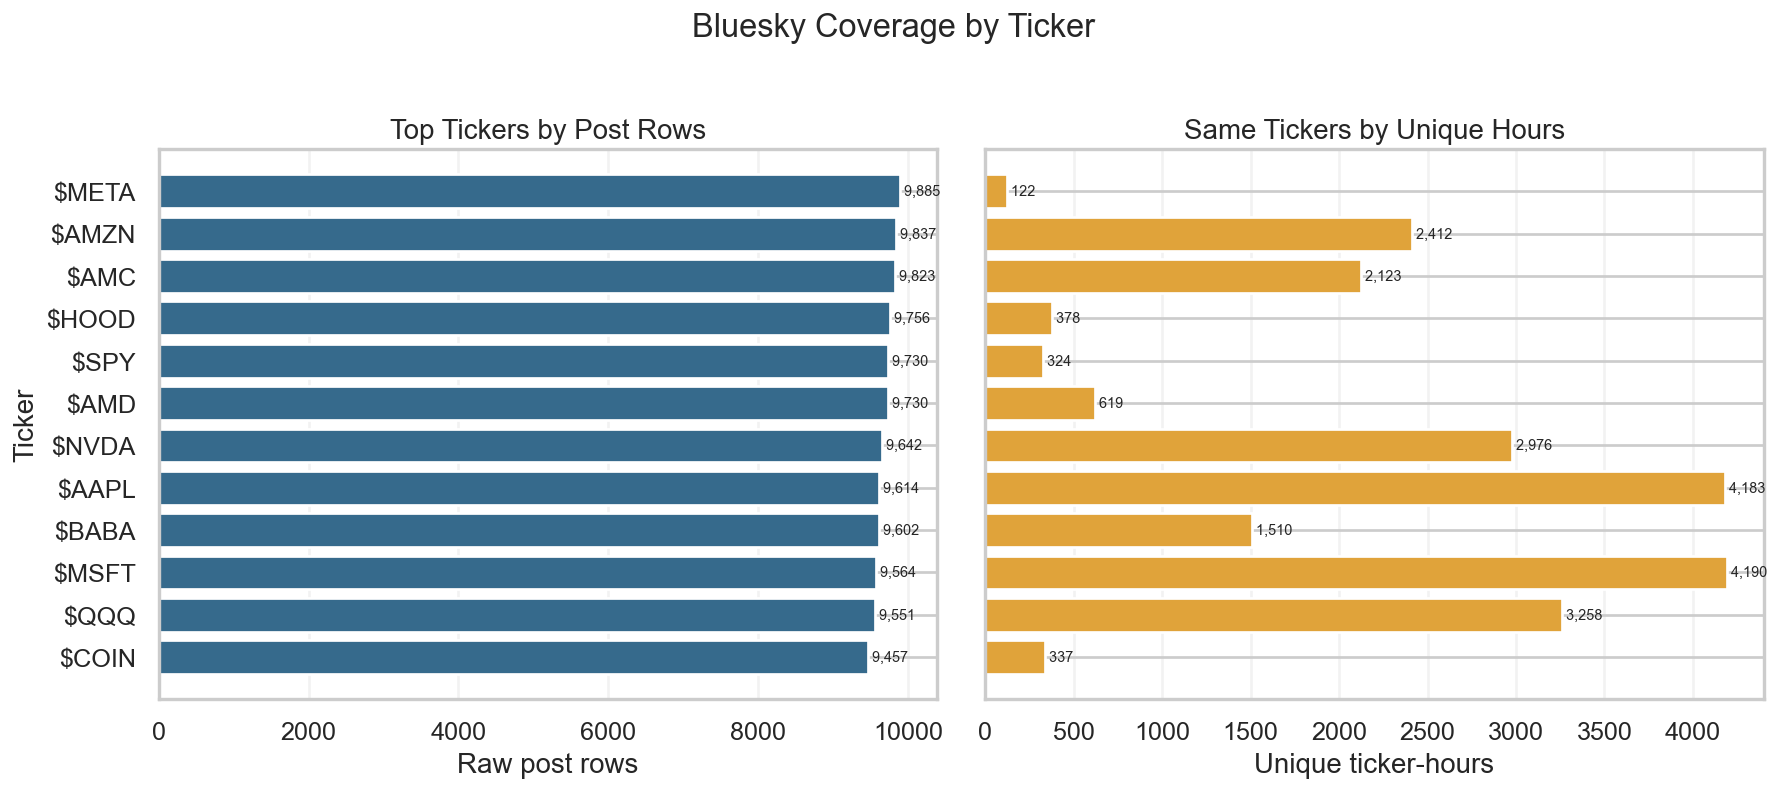

,Ticker,Raw_Post_Rows,Unique_Ticker_Hours,Avg_Sentiment
0,$META,9885,122,-0.070474
1,$AMZN,9837,2412,0.014416
2,$AMC,9823,2123,-0.010045
3,$HOOD,9756,378,-0.034201
4,$AMD,9730,619,0.028583
5,$SPY,9730,324,-0.081959
6,$NVDA,9642,2976,0.055304
7,$AAPL,9614,4183,-0.005331
8,$BABA,9602,1510,0.077116
9,$MSFT,9564,4190,-0.033327


In [3]:
ticker_counts = (
    raw_df.group_by("Ticker")
    .agg(
        [
            pl.len().alias("Raw_Post_Rows"),
            pl.col("Timestamp").n_unique().alias("Unique_Ticker_Hours"),
            pl.col("Sentiment").mean().alias("Avg_Sentiment"),
        ]
    )
    .sort("Raw_Post_Rows", descending=True)
    .to_pandas()
)

top_tickers = ticker_counts.head(12).sort_values("Raw_Post_Rows", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].barh(top_tickers["Ticker"], top_tickers["Raw_Post_Rows"], color="#366A8C")
axes[0].set_title("Top Tickers by Post Rows")
axes[0].set_xlabel("Raw post rows")
axes[0].set_ylabel("Ticker")
axes[0].grid(axis="x", alpha=0.25)
for y, value in enumerate(top_tickers["Raw_Post_Rows"]):
    axes[0].text(value, y, f" {value:,.0f}", va="center", fontsize=8)

axes[1].barh(top_tickers["Ticker"], top_tickers["Unique_Ticker_Hours"], color="#E0A33A")
axes[1].set_title("Same Tickers by Unique Hours")
axes[1].set_xlabel("Unique ticker-hours")
axes[1].grid(axis="x", alpha=0.25)
for y, value in enumerate(top_tickers["Unique_Ticker_Hours"]):
    axes[1].text(value, y, f" {value:,.0f}", va="center", fontsize=8)

fig.suptitle("Bluesky Coverage by Ticker", y=1.02, fontsize=18)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_01_ticker_coverage.png", bbox_inches="tight")
plt.show()

display(ticker_counts.head(10))


**EDA takeaway.** Attention is not evenly distributed across stocks. This supports adding ticker indicator features and evaluating combined versus intraday/overnight model scopes rather than assuming one universal sentiment pattern.


## Visual 2 - Sentiment Distribution

FinBERT produces a continuous sentiment score. We keep the continuous value for modeling, but this plot uses simple negative/neutral/positive buckets to make the distribution easier to read.


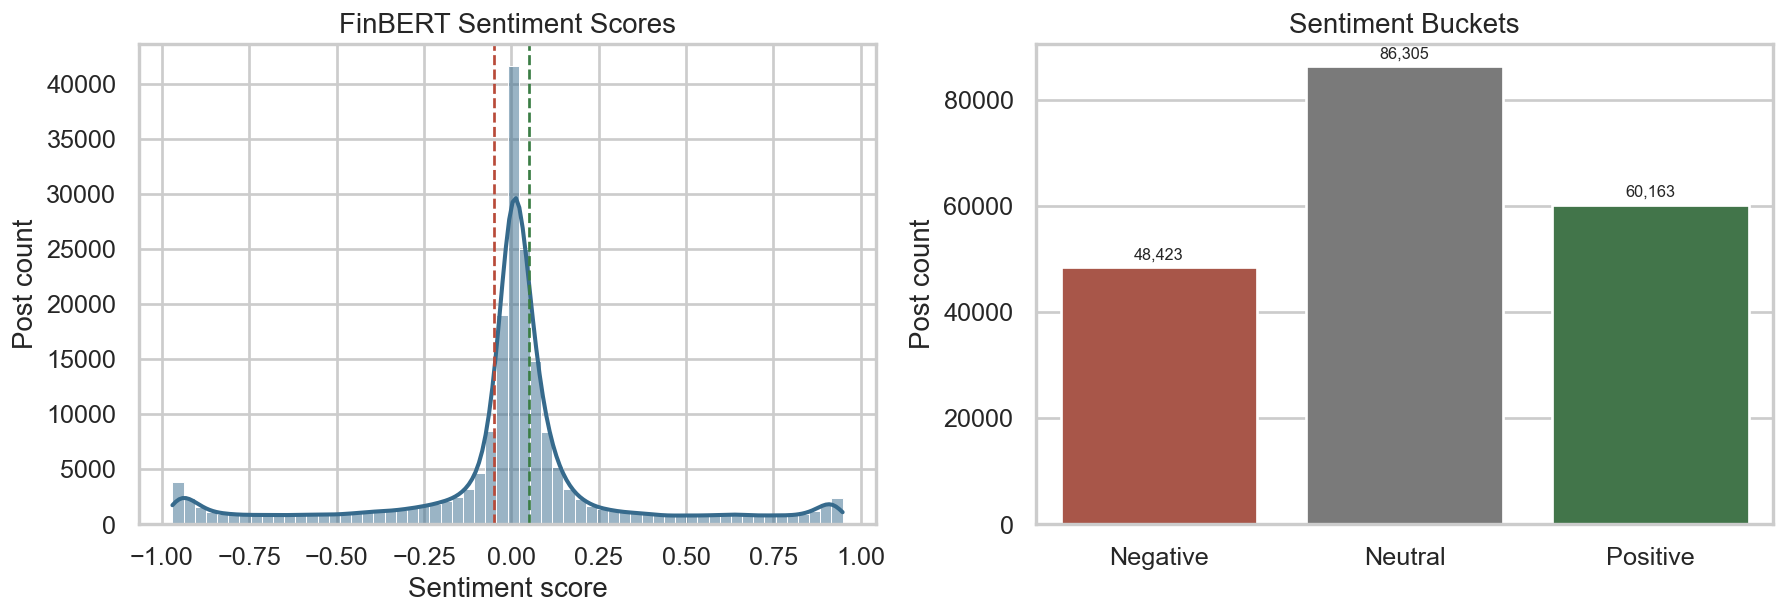

,Sentiment_Bucket,Count
0,Negative,48423
1,Neutral,86305
2,Positive,60163


In [4]:
sentiment_pdf = raw_df.select(["Ticker", "Timestamp", "Sentiment"]).to_pandas()
sentiment_pdf["Sentiment_Bucket"] = np.select(
    [
        sentiment_pdf["Sentiment"] < -0.05,
        sentiment_pdf["Sentiment"] > 0.05,
    ],
    ["Negative", "Positive"],
    default="Neutral",
)

bucket_order = ["Negative", "Neutral", "Positive"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=sentiment_pdf,
    x="Sentiment",
    bins=60,
    kde=True,
    color="#366A8C",
    ax=axes[0],
)
axes[0].axvline(-0.05, color="#B84A39", linestyle="--", linewidth=1.5)
axes[0].axvline(0.05, color="#3A7D44", linestyle="--", linewidth=1.5)
axes[0].set_title("FinBERT Sentiment Scores")
axes[0].set_xlabel("Sentiment score")
axes[0].set_ylabel("Post count")

bucket_counts = sentiment_pdf["Sentiment_Bucket"].value_counts().reindex(bucket_order).reset_index()
bucket_counts.columns = ["Sentiment_Bucket", "Count"]
sns.barplot(
    data=bucket_counts,
    x="Sentiment_Bucket",
    y="Count",
    hue="Sentiment_Bucket",
    order=bucket_order,
    hue_order=bucket_order,
    palette=["#B84A39", "#7A7A7A", "#3A7D44"],
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Sentiment Buckets")
axes[1].set_xlabel("")
axes[1].set_ylabel("Post count")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="{:,.0f}", padding=3, fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_02_sentiment_distribution.png", bbox_inches="tight")
plt.show()

display(bucket_counts)


**EDA takeaway.** Most posts are close to neutral. That means raw sentiment alone is unlikely to be a strong directional predictor, so the feature set also includes rolling sentiment, post-count anomalies, lag returns, volume anomalies, target type, and ticker indicators.


## Visual 3 - Social Activity Over Time

The raw source is social-media driven, so post volume changes over time. This plot shows monthly post activity and average sentiment after the finance coverage cutoff used in modeling.


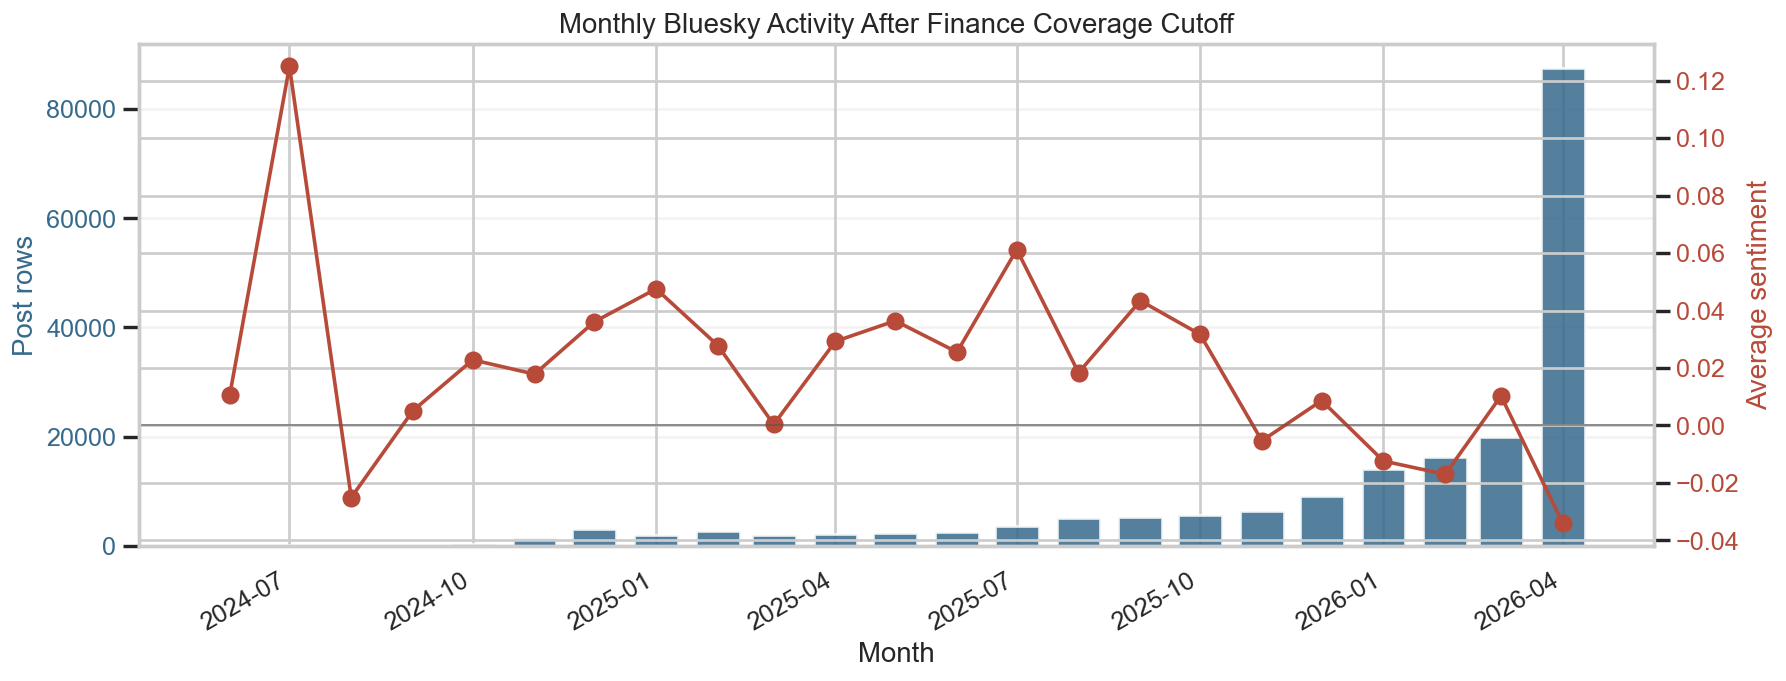

,Month,Post_Rows,Avg_Sentiment,Ticker_Count
15,2025-09-01 00:00:00+00:00,5314,0.043423,11
16,2025-10-01 00:00:00+00:00,5653,0.031696,11
17,2025-11-01 00:00:00+00:00,6360,-0.005330,12
18,2025-12-01 00:00:00+00:00,9173,0.008647,14
19,2026-01-01 00:00:00+00:00,14104,-0.012379,15
20,2026-02-01 00:00:00+00:00,16293,-0.017017,16
21,2026-03-01 00:00:00+00:00,19944,0.010268,16
22,2026-04-01 00:00:00+00:00,87583,-0.034007,23


In [5]:
recent_raw = raw_df.filter(pl.col("Timestamp") >= CLEAN_FINANCE_START)
monthly = (
    recent_raw.with_columns(pl.col("Timestamp").dt.truncate("1mo").alias("Month"))
    .group_by("Month")
    .agg(
        [
            pl.len().alias("Post_Rows"),
            pl.col("Sentiment").mean().alias("Avg_Sentiment"),
            pl.col("Ticker").n_unique().alias("Ticker_Count"),
        ]
    )
    .sort("Month")
    .to_pandas()
)

fig, ax1 = plt.subplots(figsize=(14, 5.5))
ax1.bar(monthly["Month"], monthly["Post_Rows"], width=22, color="#366A8C", alpha=0.85)
ax1.set_title("Monthly Bluesky Activity After Finance Coverage Cutoff")
ax1.set_xlabel("Month")
ax1.set_ylabel("Post rows", color="#366A8C")
ax1.tick_params(axis="y", labelcolor="#366A8C")
ax1.grid(axis="y", alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(monthly["Month"], monthly["Avg_Sentiment"], color="#B84A39", marker="o", linewidth=2.0)
ax2.axhline(0, color="#555555", linewidth=1, alpha=0.6)
ax2.set_ylabel("Average sentiment", color="#B84A39")
ax2.tick_params(axis="y", labelcolor="#B84A39")

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_03_monthly_activity_sentiment.png", bbox_inches="tight")
plt.show()

display(monthly.tail(8))


**EDA takeaway.** The project has enough recent observations for modeling, but social activity is bursty. This motivates post-count and volume anomaly features instead of treating every hour as equally informative.


## Visual 4 - Final Target Balance

The final target is a hybrid of two prediction tasks:

- **Intraday:** sentiment during a regular market hour predicts the next observed same-day market bar.
- **Overnight:** off-market sentiment predicts the next open gap from the previous market close.

Tiny moves inside the threshold are dropped so the labels represent clearer up/down moves.


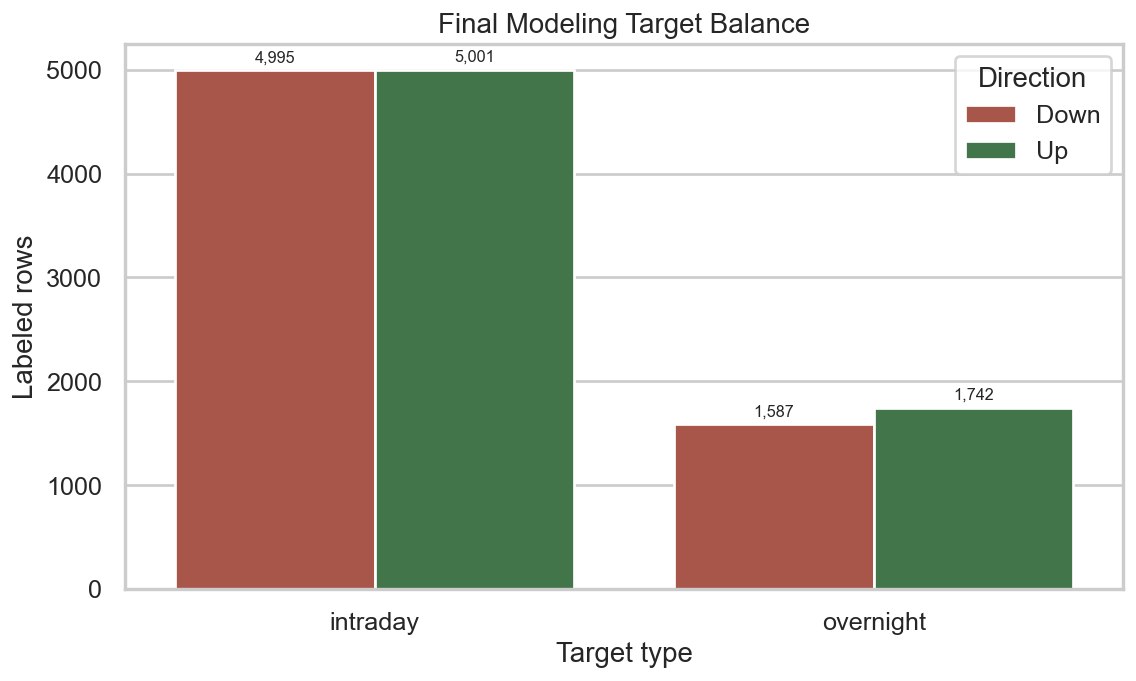

,Target_Type,Direction,len
0,intraday,Down,4995
1,intraday,Up,5001
2,overnight,Down,1587
3,overnight,Up,1742


In [6]:
target_counts = (
    feature_df.with_columns(
        pl.when(pl.col("Target_Direction") == 1)
        .then(pl.lit("Up"))
        .otherwise(pl.lit("Down"))
        .alias("Direction")
    )
    .group_by(["Target_Type", "Direction"])
    .len()
    .sort(["Target_Type", "Direction"])
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(
    data=target_counts,
    x="Target_Type",
    y="len",
    hue="Direction",
    hue_order=["Down", "Up"],
    palette=["#B84A39", "#3A7D44"],
    ax=ax,
)
ax.set_title("Final Modeling Target Balance")
ax.set_xlabel("Target type")
ax.set_ylabel("Labeled rows")
ax.legend(title="Direction")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=3, fontsize=9)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_04_target_balance.png", bbox_inches="tight")
plt.show()

display(target_counts)


**EDA takeaway.** The redesigned target is much more balanced than the old post-level baseline. This lowers the risk that a model earns high accuracy by predicting only one class.


## Visual 5 - Sentiment Signal vs Future Return

This plot checks whether sentiment has a visible relationship with the future return used as the target. It is intentionally simple: if sentiment were a very strong standalone signal, we would expect a clear monotonic separation across bins.


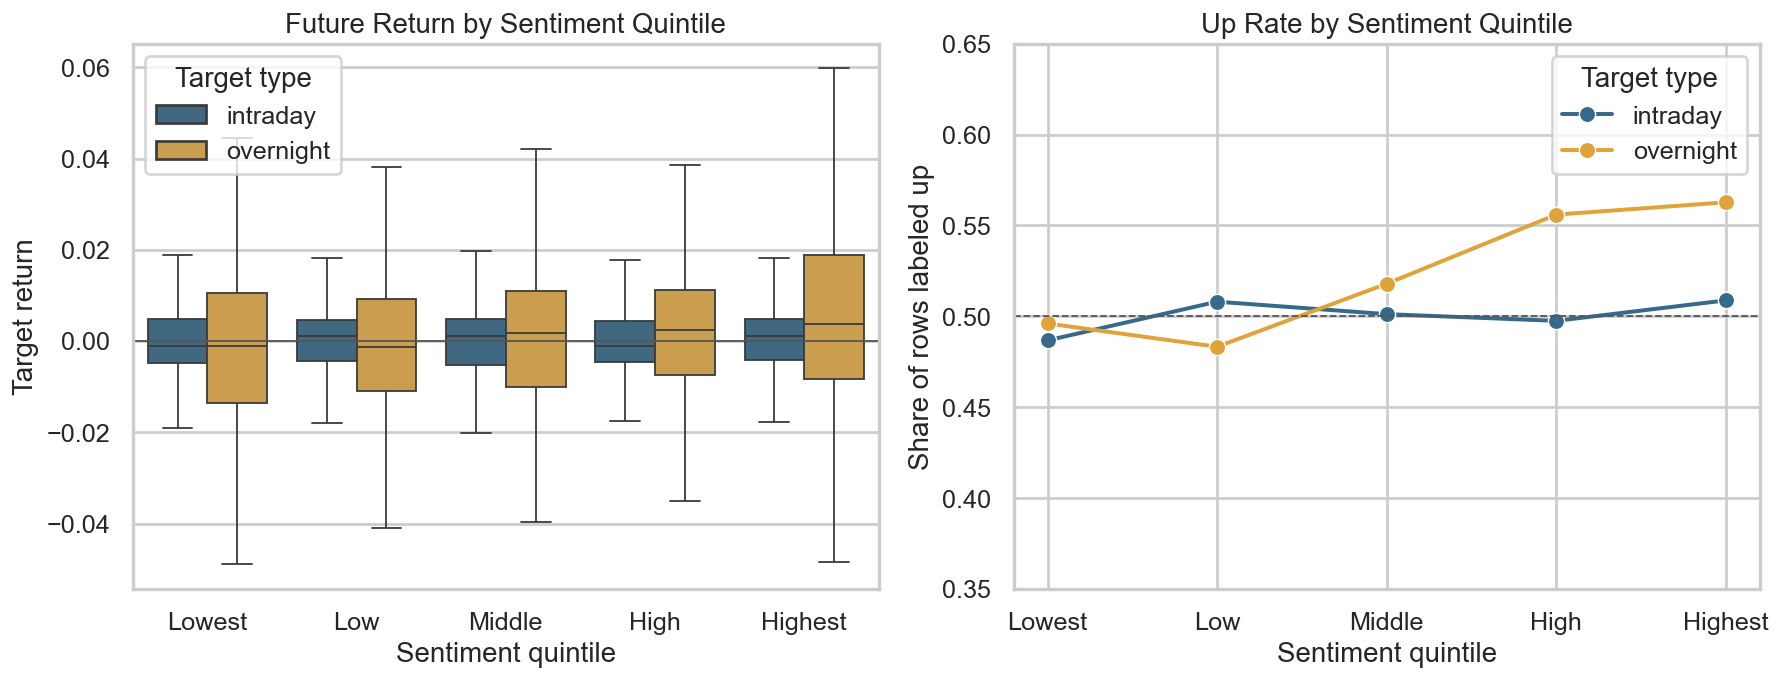

,Target_Type,Sentiment_Bin,Up_Rate
0,intraday,Lowest,0.486775
1,intraday,Low,0.508073
2,intraday,Middle,0.501219
3,intraday,High,0.497534
4,intraday,Highest,0.508780
5,overnight,Lowest,0.496078
6,overnight,Low,0.483271
7,overnight,Middle,0.517915
8,overnight,High,0.555952
9,overnight,Highest,0.562724


In [7]:
signal_pdf = feature_df.select(
    ["Target_Type", "Sentiment_Mean", "Bullishness_Index", "Post_Count", "Target_Return", "Target_Direction"]
).to_pandas()

signal_pdf["Sentiment_Bin"] = pd.qcut(
    signal_pdf["Sentiment_Mean"].rank(method="first"),
    q=5,
    labels=["Lowest", "Low", "Middle", "High", "Highest"],
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.boxplot(
    data=signal_pdf,
    x="Sentiment_Bin",
    y="Target_Return",
    hue="Target_Type",
    palette=["#366A8C", "#E0A33A"],
    showfliers=False,
    ax=axes[0],
)
axes[0].axhline(0, color="#555555", linewidth=1)
axes[0].set_title("Future Return by Sentiment Quintile")
axes[0].set_xlabel("Sentiment quintile")
axes[0].set_ylabel("Target return")
axes[0].legend(title="Target type")

up_rate = (
    signal_pdf.groupby(["Target_Type", "Sentiment_Bin"], observed=True)["Target_Direction"]
    .mean()
    .reset_index(name="Up_Rate")
)
sns.lineplot(
    data=up_rate,
    x="Sentiment_Bin",
    y="Up_Rate",
    hue="Target_Type",
    marker="o",
    palette=["#366A8C", "#E0A33A"],
    linewidth=2.2,
    ax=axes[1],
)
axes[1].axhline(0.5, color="#555555", linestyle="--", linewidth=1)
axes[1].set_title("Up Rate by Sentiment Quintile")
axes[1].set_xlabel("Sentiment quintile")
axes[1].set_ylabel("Share of rows labeled up")
axes[1].set_ylim(0.35, 0.65)
axes[1].legend(title="Target type")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_05_sentiment_vs_target.png", bbox_inches="tight")
plt.show()

display(up_rate)


**EDA takeaway.** The sentiment-return relationship is weak and noisy. That is important: our final conclusion should not overclaim predictive power. The modeling section should frame the result as a limited directional signal, then use multiple metrics to evaluate whether models improve over a naive baseline.


## Visual 6 - Example Ticker Timeline

This view is useful for presentation because it connects the actual market series with social signals. The price is indexed to 100 so it can be shown on the same chart as sentiment and post activity.


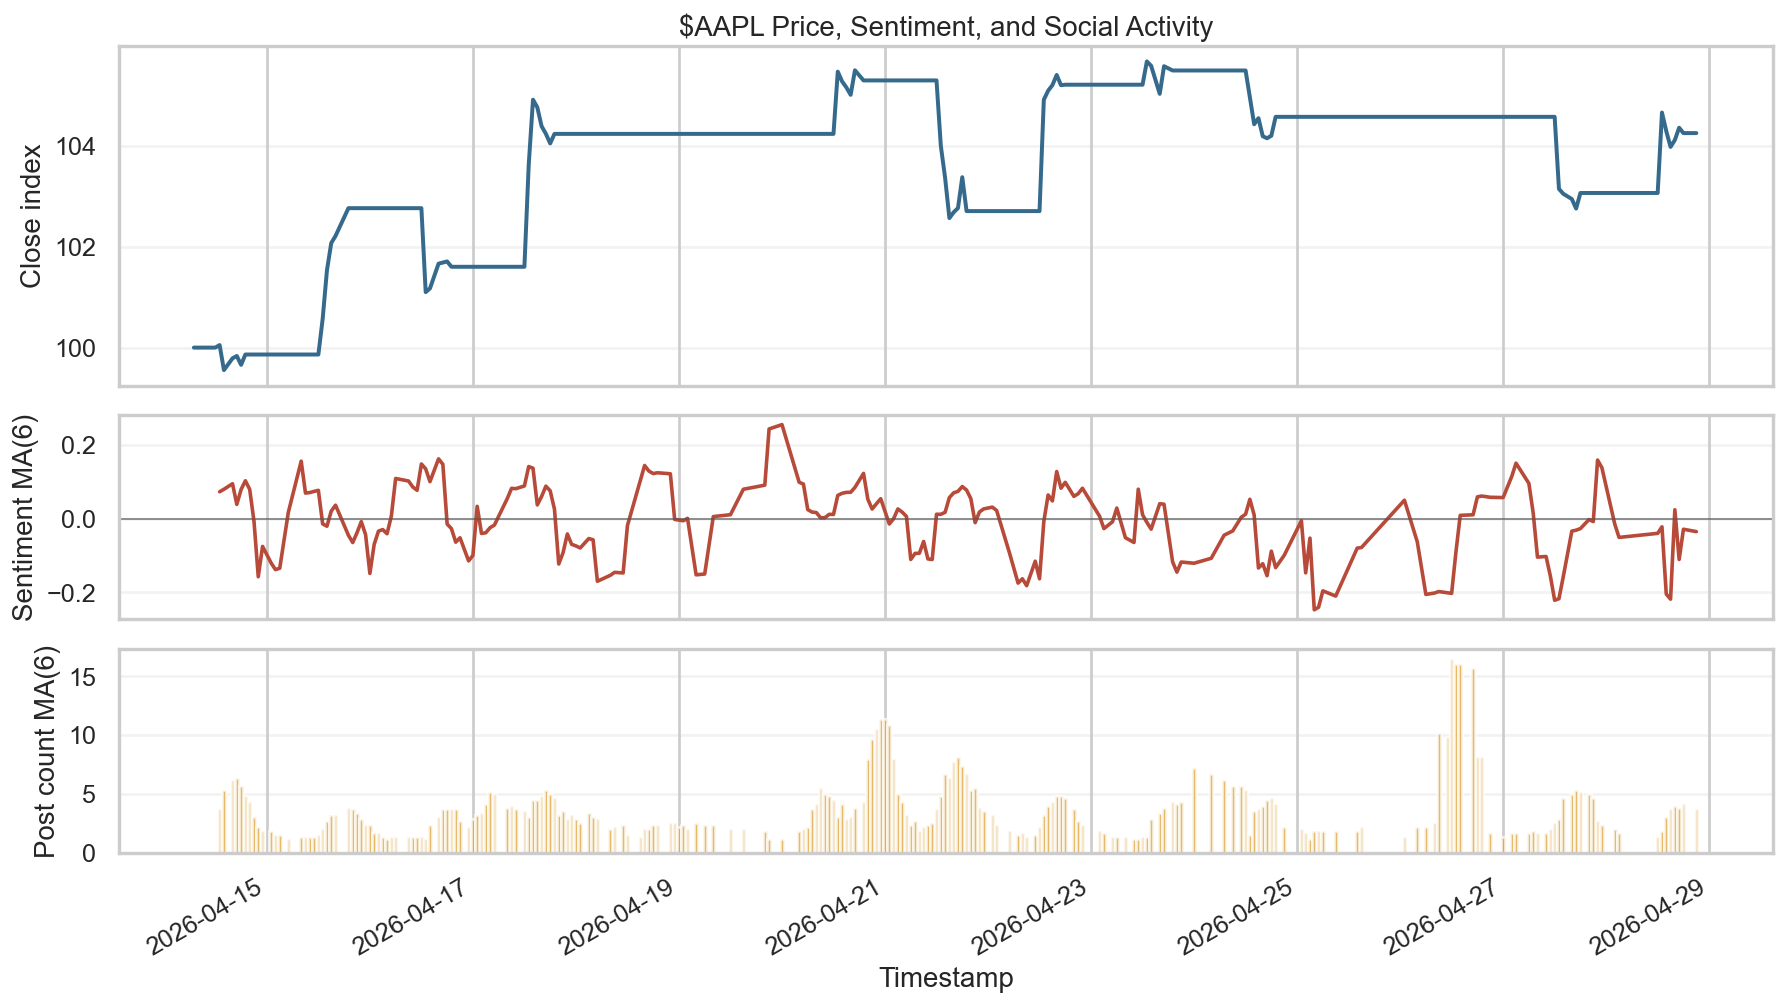

In [8]:
example_ticker = "$AAPL"
example = (
    clean_hourly_df.filter(pl.col("Ticker") == example_ticker)
    .sort("Timestamp")
    .tail(240)
    .with_columns(
        [
            (pl.col("Close") / pl.col("Close").first() * 100).alias("Close_Index"),
            pl.col("Sentiment_Mean").rolling_mean(window_size=6).alias("Sentiment_MA_6"),
            pl.col("Post_Count").rolling_mean(window_size=6).alias("Post_Count_MA_6"),
        ]
    )
    .to_pandas()
)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [2.0, 1.2, 1.2]})

axes[0].plot(example["Timestamp"], example["Close_Index"], color="#366A8C", linewidth=2.2)
axes[0].set_title(f"{example_ticker} Price, Sentiment, and Social Activity")
axes[0].set_ylabel("Close index")
axes[0].grid(axis="y", alpha=0.25)

axes[1].plot(example["Timestamp"], example["Sentiment_MA_6"], color="#B84A39", linewidth=2.0)
axes[1].axhline(0, color="#555555", linewidth=1, alpha=0.7)
axes[1].set_ylabel("Sentiment MA(6)")
axes[1].grid(axis="y", alpha=0.25)

axes[2].bar(example["Timestamp"], example["Post_Count_MA_6"], color="#E0A33A", alpha=0.75, width=0.035)
axes[2].set_ylabel("Post count MA(6)")
axes[2].set_xlabel("Timestamp")
axes[2].grid(axis="y", alpha=0.25)

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_06_example_ticker_timeline.png", bbox_inches="tight")
plt.show()


## EDA Findings and Modeling Roadmap

1. **The data volume is sufficient.** The raw merged dataset contains about 195k rows from 23 tickers, satisfying the project size requirement.
2. **Raw post rows are not the right modeling unit.** Multiple posts in one ticker-hour would overweight popular hours, so the final dataset aggregates to ticker-hour signals.
3. **Sentiment is mostly neutral and noisy.** FinBERT sentiment is useful as a signal, but it is not strong enough by itself to justify overclaiming results.
4. **Social activity is bursty.** Post counts and volume spikes are meaningful context, so the feature set includes rolling and anomaly features.
5. **The final target is rubric-safe and more realistic.** The hybrid intraday/overnight target separates market-hour and off-market prediction tasks, applies a tunable return threshold, and avoids a severely imbalanced post-level label.

These findings directly motivate the modeling notebook: chronological train/validation/test split, train-only scaling, train-only resampling comparisons, interpretable baseline models, ensemble models, hyperparameter tuning, and multiple evaluation metrics.


## Presentation Chart Checklist

Recommended slide visuals from this notebook:

- `eda_01_ticker_coverage.png`: coverage and ticker imbalance.
- `eda_02_sentiment_distribution.png`: FinBERT sentiment shape.
- `eda_04_target_balance.png`: final label balance after target redesign.
- `eda_05_sentiment_vs_target.png`: honest signal strength / limitation.
- `eda_06_example_ticker_timeline.png`: intuitive example connecting sentiment and prices.
